# RNNs with PyTorch

This notebook is a small, self-contained example of building and training a
**Recurrent Neural Network (RNN)** in PyTorch for character-level next-token
prediction — the same idea used in language modelling.

### Why RNNs (and not CNNs / feed-forward nets) for sequences?
- Sequences can be **variable length** — a feed-forward net needs a fixed
  number of inputs.
- Interactions in text can be **non-local** (a word early in a sentence can
  affect meaning much later), while CNNs are designed to capture mostly
  **local** patterns.
- An RNN keeps a **hidden state** that summarizes everything seen so far,
  and updates this state recursively at every time step:

```
h_t = tanh(W h_{t-1} + U x_t + b)      <- state update
o_t = V h_t + c                        <- output (logits)
```

We'll train a character-level RNN on a small chunk of text, so it needs no
dataset download — it learns to predict the next character given the
previous ones, and we can then use it to generate new text.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Prepare the data

We use a small piece of text as our training corpus. Each character is
converted to an integer id (like a mini one-hot vocabulary), the same idea
as word-embeddings but at the character level.

In [2]:
text = (
    "recurrent neural networks process sequences one step at a time. "
    "at each step the hidden state summarizes everything seen so far. "
    "this lets the network handle inputs of any length using the same "
    "shared weights at every time step. once trained, the model can "
    "generate new text by feeding its own predictions back as the next input."
)

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print("Corpus length:", len(text))
print("Vocabulary size:", vocab_size)
print("Vocabulary:", chars)

Corpus length: 329
Vocabulary size: 28
Vocabulary: [' ', ',', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## 2. Build training sequences

For every position in the text, the input is a window of `seq_len`
characters, and the target is the character right after that window
(i.e. next-character prediction).

In [3]:
seq_len = 25

data_idx = [char_to_idx[ch] for ch in text]

inputs = []
targets = []
for i in range(len(data_idx) - seq_len):
    inputs.append(data_idx[i:i+seq_len])
    targets.append(data_idx[i+1:i+seq_len+1])   # shifted by one -> next char at every position

X = torch.tensor(inputs, dtype=torch.long)     # (num_samples, seq_len)
Y = torch.tensor(targets, dtype=torch.long)    # (num_samples, seq_len)

print("X shape:", X.shape, " Y shape:", Y.shape)

X shape: torch.Size([304, 25])  Y shape: torch.Size([304, 25])


## 3. Define the RNN model

`Embedding -> RNN -> Linear` — this mirrors the standard
`state = f(state, embed(token))` then `logits = linear(state)` pattern.

In [4]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        e = self.embed(x)                  # (batch, seq_len, embed_dim)
        out, h_n = self.rnn(e, h0)          # out: (batch, seq_len, hidden_dim)
        logits = self.fc(out)               # (batch, seq_len, vocab_size) - one prediction per time step
        return logits, h_n

model = CharRNN(vocab_size).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", total_params)

CharRNN(
  (embed): Embedding(28, 16)
  (rnn): RNN(16, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=28, bias=True)
)
Total trainable parameters: 7516


## 4. Train the model

We use cross-entropy loss between the predicted distribution at every time
step and the true next character (teacher forcing — the input is always the
real previous characters, not the model's own past predictions).

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-3)

X_dev, Y_dev = X.to(device), Y.to(device)

num_epochs = 300
losses = []

model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    logits, _ = model(X_dev)                      # (batch, seq_len, vocab_size)
    loss = criterion(logits.reshape(-1, vocab_size), Y_dev.reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - loss: {loss.item():.4f}")

Epoch 50/300 - loss: 1.1300


Epoch 100/300 - loss: 0.3053


Epoch 150/300 - loss: 0.1925


Epoch 200/300 - loss: 0.1593


Epoch 250/300 - loss: 0.1438


Epoch 300/300 - loss: 0.1352


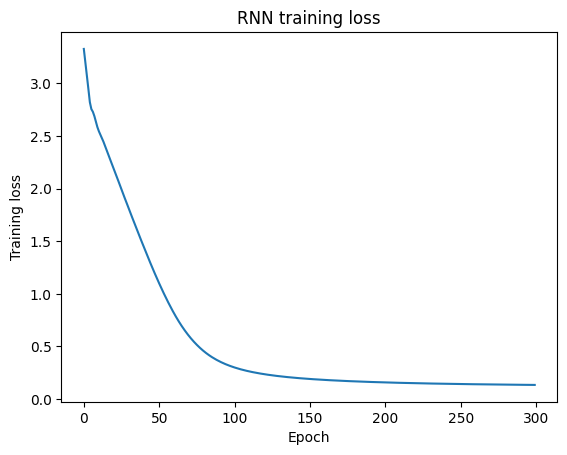

In [6]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("RNN training loss")
plt.show()

## 5. Generate text (autoregressive generation)

Now we use the trained RNN to generate new text: start with a short seed
string, predict the next character, feed it back in as input, and repeat.
This is exactly the loop shown in the course slides:
`sample -> feed back as next input -> repeat`.

In [7]:
def generate(model, seed, length=200, temperature=0.8):
    model.eval()
    chars_generated = list(seed)
    input_idx = torch.tensor([[char_to_idx[ch] for ch in seed]], dtype=torch.long).to(device)

    h = None
    with torch.no_grad():
        # warm up the hidden state on the seed text
        logits, h = model(input_idx, h)

        last_char_idx = input_idx[:, -1:]
        for _ in range(length):
            logits, h = model(last_char_idx, h)
            probs = torch.softmax(logits[0, -1] / temperature, dim=0)
            next_idx = torch.multinomial(probs, num_samples=1).item()
            chars_generated.append(idx_to_char[next_idx])
            last_char_idx = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    return "".join(chars_generated)

print(generate(model, seed="recurrent neural", length=200))

recurrent neural step the hidden state summarizes everything seen so far. this lets the network handle inputs of any length using the same shared weights at every time step. once trained, the model can generate new t


## Summary / What we learned

- An RNN processes a sequence **one token at a time**, updating a hidden
  state that carries information forward — this is what lets it handle
  variable-length input with a fixed number of parameters (the same weights
  `W`, `U`, `b` are reused at every time step).
- Training uses **teacher forcing**: the true previous tokens are fed as
  input, and the model is trained to predict the correct next token at
  every position (maximum likelihood).
- Once trained, the model can **generate** new sequences autoregressively:
  predict the next token, feed it back as input, repeat.
- This exact same next-token-prediction idea, at a larger scale with more
  data and a bigger hidden state, is the foundation of language models.

### To try next
- Use `nn.LSTM` or `nn.GRU` instead of plain `nn.RNN` (they handle longer
  range dependencies better)
- Train on a much larger text corpus for more coherent generations
- Try a bidirectional RNN for a classification task (e.g. sentiment
  analysis) instead of next-token prediction